# NHANES Project
## Part 1

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


mdf = pd.read_csv('../data/linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )

#mdf columns
mdf_cols = mdf.columns.tolist()

gdf = pd.read_sas("../data/DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )

#gdf columns
gdf_cols = gdf.columns.tolist()

df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
print( df.head() )


   SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0     1         2       NaN           NaN       NaN       NaN         NaN   
1     2         1       1.0           6.0       0.0       0.0       177.0   
2     3         2       NaN           NaN       NaN       NaN         NaN   
3     4         2       NaN           NaN       NaN       NaN         NaN   
4     5         1       0.0           NaN       NaN       NaN       244.0   

   PERMTH_EXM  
0         NaN  
1       177.0  
2         NaN  
3         NaN  
4       244.0  
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.

### Explain the four crucial variables

- ELIGSTAT: The ELIGSTAT variable indicates whether someone was eligible for mortality follow-up.
- MORTSTAT: Final mortality status of individual 
- PERMTH_INT: Number of Person Months of Follow-up from NHANES interview date 
- RIDAGEEX: Age (in months) at examination 

### Load alcohol data and start working

**Rationale for Alcohol Data**: We are going to use the alcohol data from the questionnaire data because alcohol use is associated with liver disease, cardiovascular risk, accidents, and long-term mortality. So it is likely a good predictor of mortality.

In [18]:
# load alcohol questionnaire data
adf = pd.read_sas("../data/ALQ.xpt", format="xport")
print( adf.head() )

# merge alcohol questionnaire data with the previously merged data
df = df.merge(adf, on="SEQN", how="left")

df_cols = df.columns.tolist()

df.head()

   SEQN  ALQ100  ALQ110  ALQ120Q  ALQ120U  ALQ130       ALQ140Q  ALQ140U  \
0   2.0     1.0     NaN     24.0      3.0     1.0  5.397605e-79      NaN   
1   5.0     1.0     NaN      4.0      1.0     3.0  1.200000e+01      3.0   
2   7.0     2.0     2.0      NaN      NaN     NaN           NaN      NaN   
3  10.0     1.0     NaN      6.0      3.0     1.0  5.397605e-79      NaN   
4  12.0     1.0     NaN      2.0      2.0     3.0  1.000000e+00      3.0   

   ALQ150  
0     2.0  
1     2.0  
2     NaN  
3     2.0  
4     1.0  


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,PERMTH_INT,PERMTH_EXM,ALQ100,ALQ110,ALQ120Q,ALQ120U,ALQ130,ALQ140Q,ALQ140U,ALQ150
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,177.0,177.0,1.0,NaN,24.0,3.0,1.0,5.397605e-79,NaN,2.0
2,3.0,1.0,2.0,1.0,2.0,10.0,125.0,126.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,1.0,2.0,2.0,1.0,1.0,22.0,23.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,244.0,244.0,1.0,NaN,4.0,1.0,3.0,1.200000e+01,3.0,2.0


### Performing Basic Exploratory Data Analysis and Visualization

In [19]:
# get the shape of the merged dataframe
print(f"Shape of merged dataframe: {df.shape}\n")

# check for missing values in the merged dataframe
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"Total missing values in merged dataframe: {total_missing}")
print("\nMissing values in each column:")
print(missing_values)

#check if mortstat and permth_int having missing values
print("\nMissing values in MORTSTAT and PERMTH_INT:")
print(df[['MORTSTAT', 'PERMTH_INT']].isna().sum())

Shape of merged dataframe: (9965, 159)

Total missing values in merged dataframe: 183392

Missing values in each column:
SEQN           0
SDDSRVYR       0
RIDSTATR       0
RIDEXMON     683
RIAGENDR       0
            ... 
ALQ120U     7314
ALQ130      7309
ALQ140Q     7309
ALQ140U     8986
ALQ150      6446
Length: 159, dtype: int64

Missing values in MORTSTAT and PERMTH_INT:
MORTSTAT      4520
PERMTH_INT    4520
dtype: int64


### Document the missing data
-   The merged dataframe has 9,965 rows and 159 columns, resulting in 183,392 missing values, which is approximately 15.5% of the total data. 
-   Many alcohol (ALQ) variables are going to be missing. This is largely due to NHANES survey design: alcohol questions were only asked of participants aged 20 and older, and follow-up questions were skipped for respondents who reported being non-drinkers.
-   The mortality variables, MORTSTAT and PERMTH_INT, have 4,520 missing values each. This missingness may be due to incomplete linkage in the mortality file. For now, we document it, but it will need to be addressed in modeling.
- Since alcohol data are only meaningful for adults (20+), we will keep all ages for this EDA to explore missingness and distributions. Restricting to 20+ will be done later when building the kNN models.

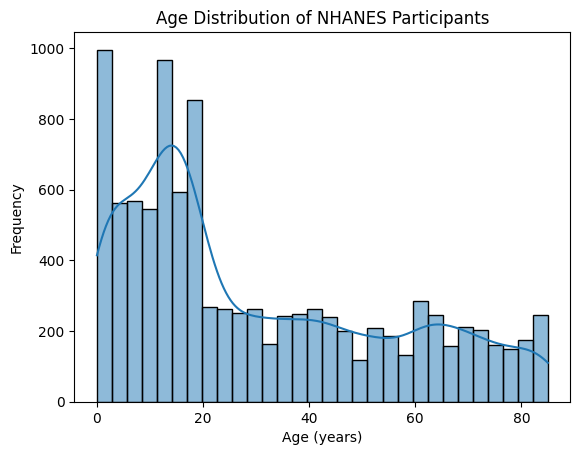

In [20]:
#  check age distribution
sns.histplot(df['RIDAGEYR'], bins=30, kde=True)
plt.title('Age Distribution of NHANES Participants')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.show()


We look at age distribution just to get a sense of frequency of different age groups and there is high frequency for ages before 20. This shows we'll be losing that much data later on when we focus on our kNN which will have to be with adults 20 and older

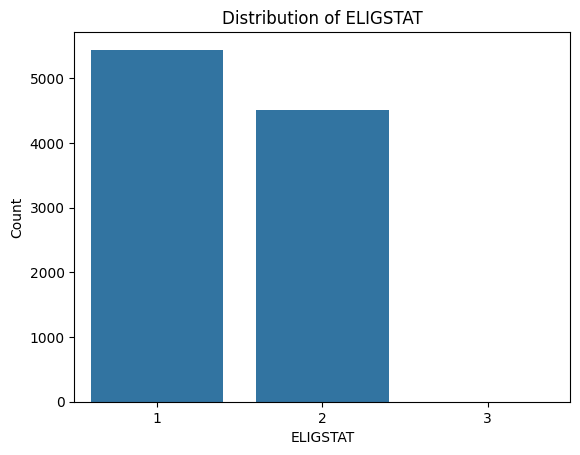

ELIGSTAT
1    5445
2    4517
3       3
Name: count, dtype: int64


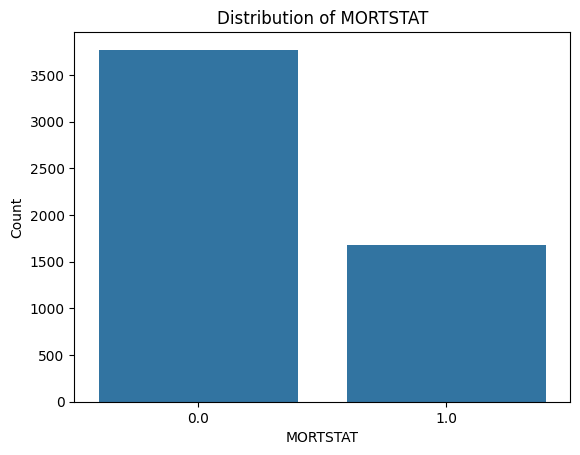

MORTSTAT
NaN    4520
0.0    3770
1.0    1675
Name: count, dtype: int64


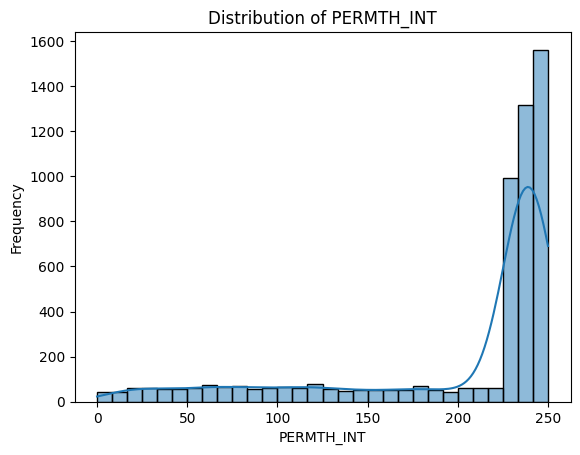

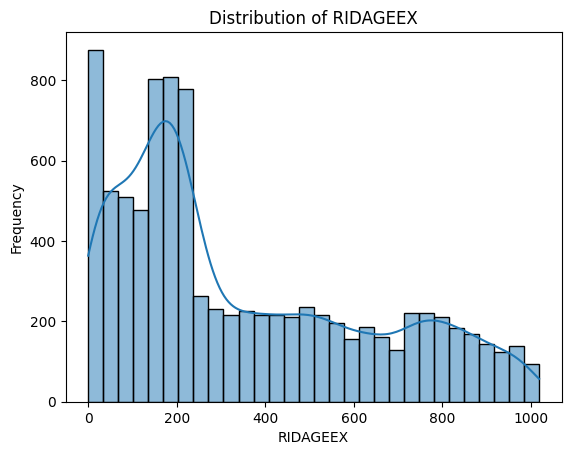

In [49]:
# ELIGSTAT, MORTSTAT, PERMTH_INT, AND RIDAGEEX are important variables. Are any of these skewed?

# count plots for ELIGSTAT and MORTSTAT along with histograms for PERMTH_INT and RIDAGEEX
sns.countplot(x='ELIGSTAT', data=df)
plt.title('Distribution of ELIGSTAT')
plt.xlabel('ELIGSTAT')
plt.ylabel('Count')
plt.show()

# value counts for ELIGSTAT
# 1 means eligible for mortality follow-up, 2 means under 18, 3 means ineligible
print(df['ELIGSTAT'].value_counts(dropna=False) )

sns.countplot(x='MORTSTAT', data=df)
plt.title('Distribution of MORTSTAT')
plt.xlabel('MORTSTAT')
plt.ylabel('Count')
plt.show()


# value counts for MORTSTAT
# 0 means alive, 1 means deceased, and NaNs are ineligible or under 18
print(df['MORTSTAT'].value_counts(dropna=False) )

sns.histplot(df['PERMTH_INT'], bins=30, kde=True)
plt.title('Distribution of PERMTH_INT')
plt.xlabel('PERMTH_INT')
plt.ylabel('Frequency')
plt.show()

sns.histplot(df['RIDAGEEX'], bins=30, kde=True)
plt.title('Distribution of RIDAGEEX')
plt.xlabel('RIDAGEEX')
plt.ylabel('Frequency')
plt.show()




- **2 of the 4 important variables mentioned in part 1 of the project instructions are skewed. PERMTH_INT is left skewed and RIDAGEEX is right skewed**
- 

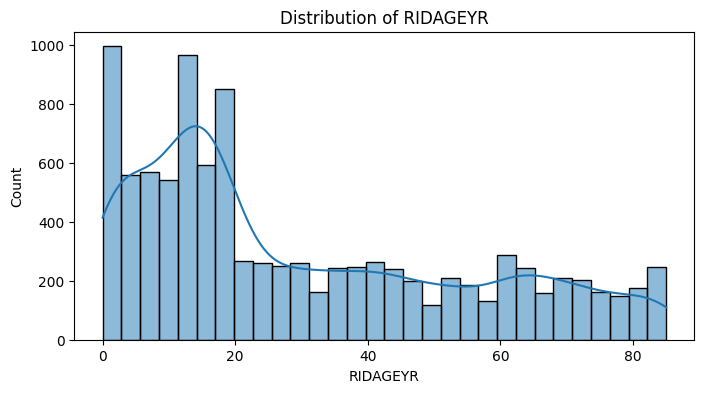

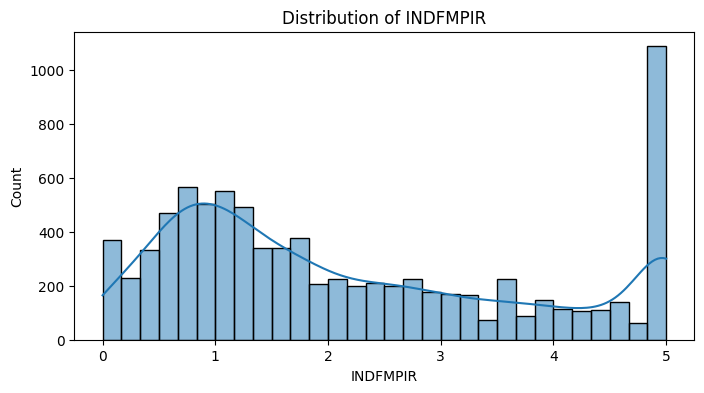

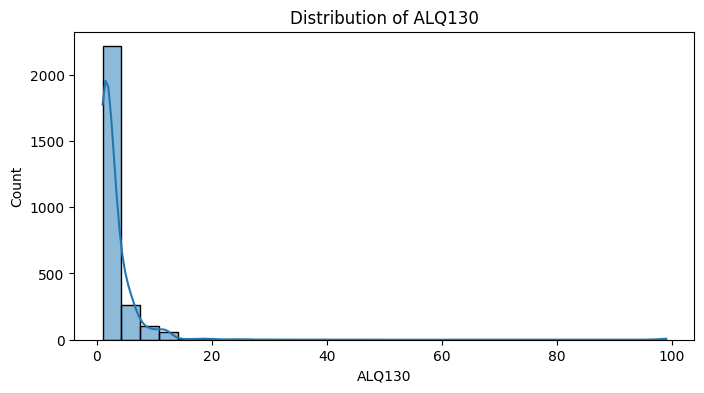

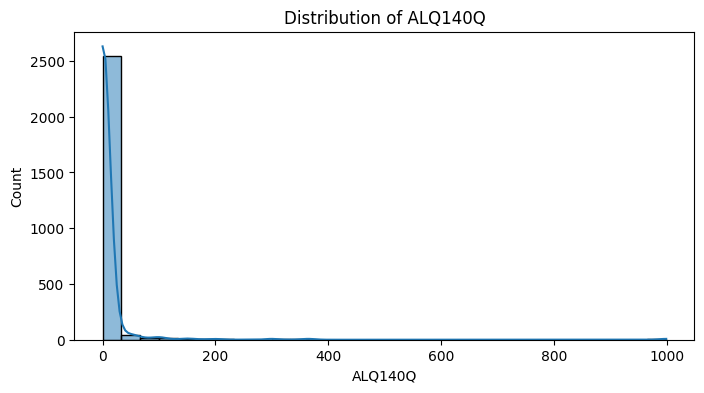

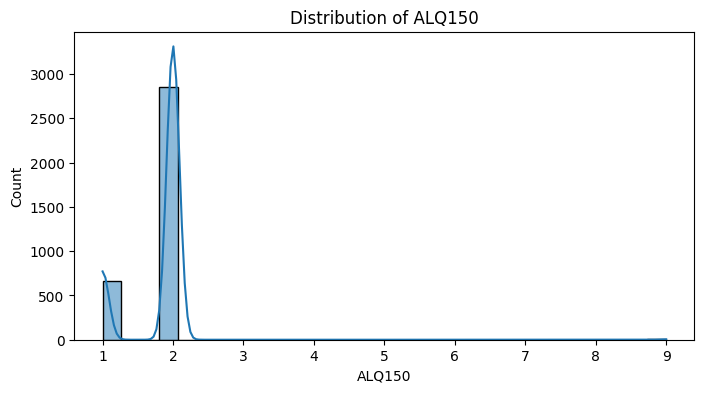

In [43]:
# visualize numeric variables
num_vars = ['RIDAGEYR', 'INDFMPIR', 'ALQ130', 'ALQ140Q', 'ALQ150']
for var in num_vars:
    plt.figure(figsize=(8,4))
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f"Distribution of {var}")
    plt.show()

# PART 2
 We restrict to adults 20+ and need to be eligible for mortality follow-up

In [ ]:
# restrict to adults 20 and up and have to be eligible for mortality follow-up (ELIGSTAT=1)
df_adults = df[(df['RIDAGEYR'] >= 20) & (df['ELIGSTAT'] == 1)].copy()

# If no drinks in past year (ALQ100=2) OR no drinks in lifetime (ALQ110=2),
# the survey skips habits. We must set these habit variables to 0/No.
filler = (df_adults['ALQ100'] == 2) | (df_adults['ALQ110'] == 2)

df_adults.loc[filler, 'ALQ130'] = 0     # Avg drinks/day
df_adults.loc[filler, 'ALQ140Q'] = 0    # Binge drinking days
df_adults.loc[filler, 'ALQ150'] = 2     # Ever 5+ drinks daily (2 = No)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# normalize numeric features using min-max scaling
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

#Feature Selection
# Predictors: Age, Gender, Race, Poverty Income, Avg Drinks, Binge Days, Drinking History
features = ['RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'ALQ130', 'ALQ140Q', 'ALQ150']
targets = ['MORTSTAT', 'PERMTH_INT']

# take subset of the dataframe with only the selected features and targets
df_adults_subset = df_adults[features + targets].copy()
print(df_adults_subset.shape)
print(df_adults_subset.head())

# check for missing values in the subset dataframe
missing_values_subset = df_adults_subset.isnull().sum()
total_missing_subset = missing_values_subset.sum()
print(f"\nTotal missing values in subset dataframe: {total_missing_subset}")
print("\nMissing values in each column of subset dataframe:")
print(missing_values_subset)

(4877, 9)
    RIDAGEYR  RIAGENDR  RIDRETH1  INDFMPIR  ALQ130       ALQ140Q  ALQ150  \
1       77.0       1.0       3.0      5.00     1.0  5.397605e-79     2.0   
4       49.0       1.0       3.0      5.00     3.0  1.200000e+01     2.0   
6       59.0       2.0       4.0       NaN     0.0  0.000000e+00     2.0   
9       43.0       1.0       4.0       NaN     1.0  5.397605e-79     2.0   
11      37.0       1.0       3.0      4.93     3.0  1.000000e+00     1.0   

    MORTSTAT  PERMTH_INT  
1        1.0       177.0  
4        0.0       244.0  
6        0.0       237.0  
9        1.0       231.0  
11       0.0       236.0  

Total missing values in subset dataframe: 3814

Missing values in each column of subset dataframe:
RIDAGEYR         0
RIAGENDR         0
RIDRETH1         0
INDFMPIR       745
ALQ130        1175
ALQ140Q       1175
ALQ150         719
MORTSTAT         0
PERMTH_INT       0
dtype: int64


In [39]:
# drop missing values and filter out NHANES "refused/dontknow" codes (7,9,77,99,777,999)
df_final = df_adults_subset.dropna()
df_final = df_final[~df_final['ALQ130'].isin([77,99])]
df_final = df_final[~df_final['ALQ140Q'].isin([777,999])]
df_final = df_final[~df_final['ALQ150'].isin([7,9])]

#check missing values in final dataframe
missing_values_final = df_final.isnull().sum()
total_missing_final = missing_values_final.sum()
print(f"\nTotal missing values in final dataframe: {total_missing_final}")
print("\nMissing values in each column of final dataframe:")
print(missing_values_final)

#check shape
print(f"\nShape of final dataframe: {df_final.shape}")
print(df_final.head())


Total missing values in final dataframe: 0

Missing values in each column of final dataframe:
RIDAGEYR      0
RIAGENDR      0
RIDRETH1      0
INDFMPIR      0
ALQ130        0
ALQ140Q       0
ALQ150        0
MORTSTAT      0
PERMTH_INT    0
dtype: int64

Shape of final dataframe: (3180, 9)
    RIDAGEYR  RIAGENDR  RIDRETH1  INDFMPIR  ALQ130       ALQ140Q  ALQ150  \
1       77.0       1.0       3.0      5.00     1.0  5.397605e-79     2.0   
4       49.0       1.0       3.0      5.00     3.0  1.200000e+01     2.0   
11      37.0       1.0       3.0      4.93     3.0  1.000000e+00     1.0   
12      70.0       1.0       1.0      1.07     2.0  5.397605e-79     2.0   
13      81.0       1.0       3.0      2.67     1.0  5.397605e-79     2.0   

    MORTSTAT  PERMTH_INT  
1        1.0       177.0  
4        0.0       244.0  
11       0.0       236.0  
12       1.0        16.0  
13       1.0       137.0  


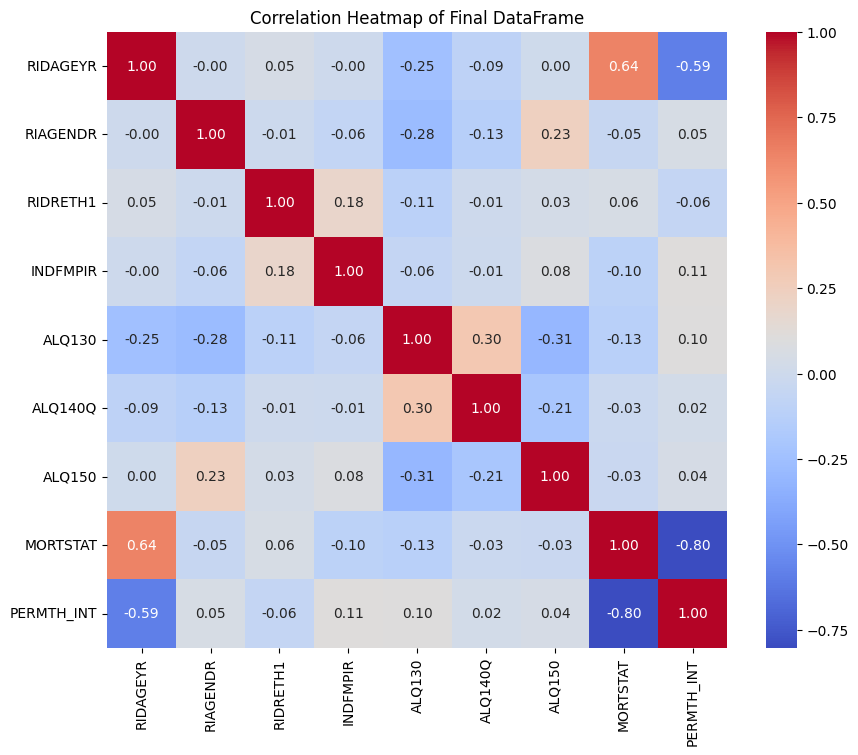

In [40]:
# correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Final DataFrame")
plt.show()